# Análisis integral de datos de Polymarket

Este notebook convierte el snapshot `data/datasets/ontology/` en un proceso completo de análisis de datos: definición de datasets, auditoría de cobertura, limpieza, EDA, feature engineering, búsqueda de reglas, señales externas y experimentos predictivos. La idea central es no empezar por el modelo, sino por comprobar si el dataset contiene suficiente información para producir insights fiables sobre mercados de Polymarket.

El análisis usa los parquet generados por `scripts/extract_market_datasets.py`, que combinan Polymarket Gamma/CLOB/Data API, UMA, Chainlink y lecturas on-chain de Polygon. Donde todavía falten fuentes como X/social signals, el notebook deja el contrato de datos esperado y valida explícitamente esa carencia para evitar conclusiones falsas.

In [1]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)

NOTEBOOK_DIR = Path.cwd()
BACKEND_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "app").exists() else NOTEBOOK_DIR
if not (BACKEND_ROOT / "app").exists():
    BACKEND_ROOT = BACKEND_ROOT / "backend"

DATA_DIR = BACKEND_ROOT / "data" / "datasets" / "ontology"
assert (DATA_DIR / "manifest.json").exists(), f"Ejecuta primero: python scripts/extract_market_datasets.py --output-dir {DATA_DIR}"

with open(DATA_DIR / "manifest.json", encoding="utf-8") as f:
    manifest = json.load(f)

def load_table(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path) if path.exists() else pd.DataFrame()

TABLES = {
    "markets": load_table("markets"),
    "price_series": load_table("price_series"),
    "trades": load_table("trades"),
    "holders": load_table("holders"),
    "market_resolution_links": load_table("market_resolution_links"),
    "resolutions": load_table("resolutions"),
    "orderbook_snapshots": load_table("orderbook_snapshots"),
    "chainlink_latest": load_table("chainlink_latest"),
    "chainlink_series": load_table("chainlink_series"),
    "contract_events": load_table("contract_events"),
    "external_signals": load_table("external_signals"),
    "wallet_activity": load_table("wallet_activity"),
}

markets_raw = TABLES["markets"]
prices_raw = TABLES["price_series"]
trades_raw = TABLES["trades"]
holders_raw = TABLES["holders"]
links_raw = TABLES["market_resolution_links"]
resolutions_raw = TABLES["resolutions"]
orderbook_raw = TABLES["orderbook_snapshots"]
chainlink_latest_raw = TABLES["chainlink_latest"]
chainlink_raw = TABLES["chainlink_series"]
contract_events_raw = TABLES["contract_events"]
external_signals_raw = TABLES["external_signals"]

row_counts = {name: len(frame) for name, frame in TABLES.items()}
print("Dataset:", DATA_DIR)
print("Creado UTC:", manifest.get("created_at_utc"))
print("quality_passed:", manifest.get("quality_passed"), "| failures:", manifest.get("quality_failures"))
print("row_counts:", row_counts)
print("join_coverage:", manifest.get("join_coverage"))

Dataset: /home/src/data/datasets/ontology
Creado UTC: 2026-06-02T16:42:44.739388+00:00
quality_passed: True | failures: []
row_counts: {'markets': 120, 'price_series': 3661, 'trades': 8600, 'holders': 237, 'market_resolution_links': 25, 'resolutions': 200, 'orderbook_snapshots': 119, 'chainlink_latest': 24, 'chainlink_series': 1464, 'contract_events': 0, 'external_signals': 0}
join_coverage: {'markets_total': 120, 'pct_with_trades': 71.7, 'pct_with_holders': 99.2, 'pct_with_chainlink_feed': 35.8, 'pct_with_price_series': 50.0, 'pct_with_chainlink_series': 20.0, 'uma_links_in_sample': 25, 'pct_uma_linked': 20.8, 'chainlink_series_rows': 1464}


## 0. Diseño del dataset antes del análisis

Un buen análisis de Polymarket necesita varias capas porque el precio YES no se explica solo con metadata del mercado. En este notebook tratamos cada mercado como una entidad temporal con información de catálogo, microestructura, actividad de usuarios, resolución/oráculo y señales externas.

**Fuentes y propósito analítico:**

| Capa | Fuente | Dataset esperado | Preguntas que permite responder |
|---|---|---|---|
| Catálogo | Polymarket Gamma API / PostgreSQL `markets` | `markets` | Qué mercados existen, categoría, estado, liquidez, volumen, reglas textuales, tokens CLOB. |
| Precio y order book | Polymarket CLOB API | `price_series`, `orderbook_snapshots` | Cómo se mueve la probabilidad, spread, profundidad, estabilidad, fricción y liquidez efectiva. |
| Trades y holders | Polymarket Data API | `trades`, `holders`, idealmente `wallet_activity` | Concentración, presión compradora/vendedora, wallets dominantes, mercados con holders pero sin actividad reciente. |
| Resolución | UMA + metadata Gamma | `resolutions`, `market_resolution_links` | Coherencia entre estado de resolución, disputas, proposed/resolved y cierre del mercado. |
| Datos externos financieros | Chainlink sobre Polygon | `chainlink_series`, `chainlink_latest` | Divergencias entre precio del mundo real y probabilidad de mercados crypto/financieros. |
| Eventos on-chain | Polygon logs / contratos CTF, exchange, UMA adapter | `contract_events` | Actividad real de contratos, redeem/split/merge, eventos que no aparecen completos en APIs Web2. |
| Señales sociales/noticias | X, RSS, fuentes del `resolution_source` | `external_signals` | Shocks informativos, narrativa, menciones, sentimiento y contexto de resolución.

El snapshot actual puede analizarse, pero no todas las capas están llenas. Por eso la primera parte del notebook audita cobertura y suficiencia antes de buscar patrones: si una fuente falta o solo cubre un subconjunto pequeño, las conclusiones se segmentan por cohorte en vez de generalizarse a todo Polymarket.

In [2]:
dataset_contract = pd.DataFrame([
    {
        "dataset": "markets",
        "source": "Polymarket Gamma API + PostgreSQL",
        "grain": "1 fila por market_id",
        "required_for": "universo, cohortes, joins, reglas textuales",
        "minimum": 100,
    },
    {
        "dataset": "price_series",
        "source": "Polymarket CLOB prices-history",
        "grain": "market_id, token_id, timestamp, interval",
        "required_for": "series temporales, volatilidad, momentum, modelos",
        "minimum": 2000,
    },
    {
        "dataset": "orderbook_snapshots",
        "source": "Polymarket CLOB book",
        "grain": "market_id, token_id, snapshot",
        "required_for": "spread, midpoint, profundidad, filtros de liquidez",
        "minimum": 80,
    },
    {
        "dataset": "trades",
        "source": "Polymarket Data API trades",
        "grain": "trade / wallet / market_id",
        "required_for": "microestructura, concentración, presión de flujo",
        "minimum": 5000,
    },
    {
        "dataset": "holders",
        "source": "Polymarket Data API holders",
        "grain": "holder / outcome / market_id",
        "required_for": "concentración de posiciones",
        "minimum": 100,
    },
    {
        "dataset": "market_resolution_links",
        "source": "UMA + Gamma",
        "grain": "market_id enlazado a resolución",
        "required_for": "coherencia de resolución y disputas",
        "minimum": 15,
    },
    {
        "dataset": "chainlink_series",
        "source": "Chainlink feeds en Polygon",
        "grain": "market_id, asset_pair, timestamp",
        "required_for": "divergencias mundo real vs probabilidad",
        "minimum": 500,
    },
    {
        "dataset": "contract_events",
        "source": "Polygon logs / CTF / exchange / UMA adapter",
        "grain": "evento on-chain",
        "required_for": "validación de actividad y resolución on-chain",
        "minimum": 1,
    },
    {
        "dataset": "external_signals",
        "source": "X / noticias / RSS / resolution_source",
        "grain": "señal textual con timestamp y url",
        "required_for": "shocks informativos y análisis narrativo",
        "minimum": 1,
    },
])

dataset_contract["rows_actuales"] = dataset_contract["dataset"].map(row_counts).fillna(0).astype(int)
dataset_contract["cumple_minimo"] = dataset_contract["rows_actuales"] >= dataset_contract["minimum"]
dataset_contract["gap"] = (dataset_contract["minimum"] - dataset_contract["rows_actuales"]).clip(lower=0)

display(dataset_contract.sort_values(["cumple_minimo", "dataset"]))

,dataset,source,grain,required_for,minimum,rows_actuales,cumple_minimo,gap
7,contract_events,Polygon logs / CTF / exchange / UMA adapter,evento on-chain,validación de actividad y resolución on-chain,1,0,False,1
8,external_signals,X / noticias / RSS / resolution_source,señal textual con timestamp y url,shocks informativos y análisis narrativo,1,0,False,1
6,chainlink_series,Chainlink feeds en Polygon,"market_id, asset_pair, timestamp",divergencias mundo real vs probabilidad,500,1464,True,0
4,holders,Polymarket Data API holders,holder / outcome / market_id,concentración de posiciones,100,237,True,0
5,market_resolution_links,UMA + Gamma,market_id enlazado a resolución,coherencia de resolución y disputas,15,25,True,0
0,markets,Polymarket Gamma API + PostgreSQL,1 fila por market_id,"universo, cohortes, joins, reglas textuales",100,120,True,0
2,orderbook_snapshots,Polymarket CLOB book,"market_id, token_id, snapshot","spread, midpoint, profundidad, filtros de liquidez",80,119,True,0
1,price_series,Polymarket CLOB prices-history,"market_id, token_id, timestamp, interval","series temporales, volatilidad, momentum, modelos",2000,3661,True,0
3,trades,Polymarket Data API trades,trade / wallet / market_id,"microestructura, concentración, presión de flujo",5000,8600,True,0


### 0.1 Auditoría de suficiencia

La pregunta no es solo cuántas filas existen, sino si cada mercado tiene suficientes capas para soportar el tipo de insight que queremos extraer. Un mercado puede servir para EDA de catálogo aunque no tenga Chainlink; en cambio, no sirve para divergencia financiera si no existe un feed externo alineado. Por eso calculamos una matriz de cobertura y un score de suficiencia por mercado.

La lectura recomendada es:

- **`analysis_ready`**: mercado con metadata, precios, trades y libro; útil para EDA y reglas generales.
- **`divergence_ready`**: además tiene Chainlink alineado; útil para detectar gaps con datos financieros externos.
- **`resolution_ready`**: tiene enlace UMA; útil para auditar coherencia de resolución.
- **`social_ready`**: tiene señales externas; útil para relacionar shocks de información con movimientos de precio.
- **`onchain_ready`**: tiene eventos de Polygon; útil para confirmar actividad contractual independiente de APIs Web2.

In [3]:
def unique_ids(frame: pd.DataFrame, column: str = "market_id") -> set[str]:
    if frame.empty or column not in frame.columns:
        return set()
    return set(frame[column].dropna().astype(str))

market_ids = unique_ids(markets_raw)
coverage_audit = markets_raw[["market_id", "title", "cohort", "closed", "chainlink_asset_pair"]].copy()
coverage_audit["market_id"] = coverage_audit["market_id"].astype(str)
coverage_audit["has_prices"] = coverage_audit["market_id"].isin(unique_ids(prices_raw))
coverage_audit["has_orderbook"] = coverage_audit["market_id"].isin(unique_ids(orderbook_raw))
coverage_audit["has_trades"] = coverage_audit["market_id"].isin(unique_ids(trades_raw))
coverage_audit["has_holders"] = coverage_audit["market_id"].isin(unique_ids(holders_raw))
coverage_audit["has_uma"] = coverage_audit["market_id"].isin(unique_ids(links_raw))
coverage_audit["has_chainlink"] = coverage_audit["market_id"].isin(unique_ids(chainlink_raw))
coverage_audit["has_contract_events"] = coverage_audit["market_id"].isin(unique_ids(contract_events_raw))
coverage_audit["has_external_signals"] = coverage_audit["market_id"].isin(unique_ids(external_signals_raw))

feature_flags = [
    "has_prices",
    "has_orderbook",
    "has_trades",
    "has_holders",
    "has_uma",
    "has_chainlink",
    "has_contract_events",
    "has_external_signals",
]
coverage_audit["coverage_score"] = coverage_audit[feature_flags].mean(axis=1)
coverage_audit["analysis_ready"] = coverage_audit[["has_prices", "has_orderbook", "has_trades"]].all(axis=1)
coverage_audit["divergence_ready"] = coverage_audit[["has_prices", "has_chainlink"]].all(axis=1)
coverage_audit["resolution_ready"] = coverage_audit["has_uma"]
coverage_audit["social_ready"] = coverage_audit["has_external_signals"]
coverage_audit["onchain_ready"] = coverage_audit["has_contract_events"]

coverage_summary = pd.DataFrame({
    "metrica": feature_flags + ["analysis_ready", "divergence_ready", "resolution_ready", "social_ready", "onchain_ready"],
})
coverage_summary["markets"] = coverage_summary["metrica"].map(lambda col: int(coverage_audit[col].sum()))
coverage_summary["pct_markets"] = (100 * coverage_summary["markets"] / max(len(coverage_audit), 1)).round(1)

display(coverage_summary)
print("Mercados analysis_ready:", int(coverage_audit["analysis_ready"].sum()), "de", len(coverage_audit))
print("Mercados divergence_ready:", int(coverage_audit["divergence_ready"].sum()), "de", len(coverage_audit))
print("Fuentes críticas ausentes:", dataset_contract.loc[~dataset_contract["cumple_minimo"], "dataset"].tolist())

,metrica,markets,pct_markets
0,has_prices,60,50.0
1,has_orderbook,119,99.2
2,has_trades,86,71.7
3,has_holders,119,99.2
4,has_uma,25,20.8
5,has_chainlink,24,20.0
6,has_contract_events,0,0.0
7,has_external_signals,0,0.0
8,analysis_ready,60,50.0
9,divergence_ready,24,20.0


Mercados analysis_ready: 60 de 120
Mercados divergence_ready: 24 de 120
Fuentes críticas ausentes: ['contract_events', 'external_signals']


In [4]:
ingestion_actions = pd.DataFrame([
    {
        "prioridad": 1,
        "dataset": "price_series",
        "accion": "Aumentar ventana histórica y granularidad mixta",
        "endpoint_o_fuente": "CLOB /prices-history o /batch-prices-history",
        "criterio_de_exito": ">= 90 dias para mercados activos, >= 30 puntos por mercado para modelos simples",
    },
    {
        "prioridad": 2,
        "dataset": "trades",
        "accion": "Paginar más allá del límite actual por mercado",
        "endpoint_o_fuente": "Data API /trades con offset/checkpoint",
        "criterio_de_exito": "No depender del tope de 100 trades; capturar flujo temporal y wallets recurrentes",
    },
    {
        "prioridad": 3,
        "dataset": "wallet_activity",
        "accion": "Persistir actividad de wallets dominantes",
        "endpoint_o_fuente": "Data API /activity",
        "criterio_de_exito": "Top wallets con historial cross-market para detectar smart money o wash-like behavior",
    },
    {
        "prioridad": 4,
        "dataset": "contract_events",
        "accion": "Decodificar logs de Polygon para CTF/Exchange/UMA",
        "endpoint_o_fuente": "Polygon RPC / Etherscan-compatible logs",
        "criterio_de_exito": "Eventos redeem/split/merge/fill enlazados por condition_id o token_id",
    },
    {
        "prioridad": 5,
        "dataset": "chainlink_series",
        "accion": "Ampliar matching de feeds y rango temporal",
        "endpoint_o_fuente": "Chainlink latestRoundData + AnswerUpdated logs en Polygon",
        "criterio_de_exito": "Series externas alineadas para todos los mercados financieros/crypto detectables",
    },
    {
        "prioridad": 6,
        "dataset": "external_signals",
        "accion": "Añadir señales sociales y noticias con timestamps",
        "endpoint_o_fuente": "X API/search recent, RSS, fuentes de resolution_source",
        "criterio_de_exito": "Al menos volumen de menciones, URLs, texto normalizado y ventana de impacto por mercado",
    },
])

display(ingestion_actions.sort_values("prioridad"))

,prioridad,dataset,accion,endpoint_o_fuente,criterio_de_exito
0,1,price_series,Aumentar ventana histórica y granularidad mixta,CLOB /prices-history o /batch-prices-history,">= 90 dias para mercados activos, >= 30 puntos por mercado para modelos simples"
1,2,trades,Paginar más allá del límite actual por mercado,Data API /trades con offset/checkpoint,No depender del tope de 100 trades; capturar flujo temporal y wallets recurrentes
2,3,wallet_activity,Persistir actividad de wallets dominantes,Data API /activity,Top wallets con historial cross-market para detectar smart money o wash-like behavior
3,4,contract_events,Decodificar logs de Polygon para CTF/Exchange/UMA,Polygon RPC / Etherscan-compatible logs,Eventos redeem/split/merge/fill enlazados por condition_id o token_id
4,5,chainlink_series,Ampliar matching de feeds y rango temporal,Chainlink latestRoundData + AnswerUpdated logs en Polygon,Series externas alineadas para todos los mercados financieros/crypto detectables
5,6,external_signals,Añadir señales sociales y noticias con timestamps,"X API/search recent, RSS, fuentes de resolution_source","Al menos volumen de menciones, URLs, texto normalizado y ventana de impacto por mercado"


## 1. Limpieza y calidad de tablas

Antes de cruzar endpoints normalizamos tipos, descartamos filas inválidas y documentamos cuánto material queda utilizable. Los porcentajes de la celda siguiente son la base para decidir si un join tiene sentido estadístico.


### 1.1 Normalización y filtros


In [5]:
clean_log = []

# --- markets ---
markets = markets_raw.copy()
markets["market_id"] = markets["market_id"].astype(str)
for col in ("liquidity", "volume", "volume24hr", "spread", "best_bid", "best_ask"):
    if col in markets.columns:
        markets[col] = pd.to_numeric(markets[col], errors="coerce")
clean_log.append(f"markets: {len(markets)} filas tras tipado")

# --- price_series ---
prices = prices_raw.copy()
if len(prices):
    prices["market_id"] = prices["market_id"].astype(str)
    prices["price"] = pd.to_numeric(prices["price"], errors="coerce")
    prices["timestamp_unix"] = pd.to_numeric(prices["timestamp_unix"], errors="coerce")
    n0 = len(prices)
    prices = prices.dropna(subset=["market_id", "timestamp_unix", "price"])
    prices = prices[(prices["price"] >= 0) & (prices["price"] <= 1)]
    clean_log.append(f"price_series: {n0} -> {len(prices)} (sin null, precio en [0,1])")

# --- trades ---
trades = trades_raw.copy()
if len(trades):
    trades["market_id"] = trades["market_id"].astype(str)
    trades["price"] = pd.to_numeric(trades["price"], errors="coerce")
    trades["size"] = pd.to_numeric(trades["size"], errors="coerce")
    n0 = len(trades)
    trades = trades.dropna(subset=["market_id"])
    trades = trades[(trades["size"].fillna(0) > 0) | (trades["price"].notna())]
    clean_log.append(f"trades: {n0} -> {len(trades)}")

# --- holders ---
holders = holders_raw.copy()
if len(holders):
    holders["market_id"] = holders["market_id"].astype(str)
    holders["balance"] = pd.to_numeric(holders["balance"], errors="coerce")
    clean_log.append(f"holders: {len(holders)} filas")

# --- links / chainlink ---
links = links_raw.copy()
if len(links):
    links["market_id"] = links["market_id"].astype(str)
chainlink = chainlink_raw.copy()
if len(chainlink):
    chainlink["market_id"] = chainlink["market_id"].astype(str)
    chainlink["market_price_yes"] = pd.to_numeric(chainlink["market_price_yes"], errors="coerce")
    chainlink["chainlink_price_usd"] = pd.to_numeric(chainlink["chainlink_price_usd"], errors="coerce")

for line in clean_log:
    print(line)

null_prices = prices["price"].isna().mean() * 100 if len(prices) else 0
print(f"Precios nulos tras limpieza: {null_prices:.2f}%")

markets: 120 filas tras tipado
price_series: 3661 -> 3661 (sin null, precio en [0,1])
trades: 8600 -> 8600
holders: 237 filas
Precios nulos tras limpieza: 0.00%


### 1.2 Tabla analítica por mercado

Después de limpiar las tablas crudas, construimos una tabla `market_features` con una fila por mercado. Esta tabla es el puente entre EDA, reglas y modelos: combina liquidez, actividad, volatilidad, concentración, cobertura de oráculos y flags de suficiencia. Mantener esta tabla explícita evita que cada sección calcule métricas distintas con supuestos incompatibles.

In [6]:
def gini(values: pd.Series) -> float:
    arr = pd.to_numeric(values, errors="coerce").dropna().to_numpy(dtype=float)
    arr = arr[arr >= 0]
    if len(arr) == 0 or np.isclose(arr.sum(), 0):
        return np.nan
    arr = np.sort(arr)
    n = len(arr)
    return float((2 * np.arange(1, n + 1) @ arr) / (n * arr.sum()) - (n + 1) / n)

market_features = markets.set_index("market_id").copy()

if len(prices):
    price_agg = prices.groupby("market_id").agg(
        price_points=("price", "size"),
        price_mean=("price", "mean"),
        price_last=("price", "last"),
        price_min=("price", "min"),
        price_max=("price", "max"),
        price_std=("price", "std"),
        price_unique=("price", "nunique"),
    )
    price_agg["price_range"] = price_agg["price_max"] - price_agg["price_min"]
    market_features = market_features.join(price_agg, how="left")

if len(trades):
    trades["notional"] = pd.to_numeric(trades.get("price"), errors="coerce") * pd.to_numeric(trades.get("size"), errors="coerce")
    trade_agg = trades.groupby("market_id").agg(
        n_trades=("market_id", "size"),
        wallets_trading=("wallet", "nunique") if "wallet" in trades.columns else ("market_id", "size"),
        trade_notional=("notional", "sum"),
        avg_trade_size=("size", "mean"),
    )
    market_features = market_features.join(trade_agg, how="left")

if len(holders):
    holder_agg = holders.groupby("market_id").agg(
        n_holders=("wallet", "nunique") if "wallet" in holders.columns else ("market_id", "size"),
        holder_balance=("balance", "sum"),
        holder_gini=("balance", gini),
        max_holder_balance=("balance", "max"),
    )
    holder_agg["top_holder_share"] = holder_agg["max_holder_balance"] / holder_agg["holder_balance"].replace(0, np.nan)
    market_features = market_features.join(holder_agg, how="left")

if len(orderbook_raw):
    ob = orderbook_raw.copy()
    ob["market_id"] = ob["market_id"].astype(str)
    for col in ["spread", "mid_price", "bid_depth_top10", "ask_depth_top10"]:
        if col in ob.columns:
            ob[col] = pd.to_numeric(ob[col], errors="coerce")
    ob_cols = [c for c in ["spread", "mid_price", "bid_depth_top10", "ask_depth_top10"] if c in ob.columns]
    if ob_cols:
        market_features = market_features.join(ob.groupby("market_id")[ob_cols].median(), how="left", rsuffix="_ob")

coverage_cols = ["analysis_ready", "divergence_ready", "resolution_ready", "social_ready", "onchain_ready", "coverage_score"]
market_features = market_features.join(coverage_audit.set_index("market_id")[coverage_cols], how="left")

numeric_fill_zero = ["price_points", "n_trades", "wallets_trading", "n_holders", "trade_notional", "holder_balance"]
for col in numeric_fill_zero:
    if col in market_features.columns:
        market_features[col] = market_features[col].fillna(0)

feature_preview_cols = [
    "title", "cohort", "liquidity", "volume", "price_points", "price_std", "price_range",
    "n_trades", "wallets_trading", "n_holders", "holder_gini", "spread", "coverage_score",
    "analysis_ready", "divergence_ready",
]
feature_preview_cols = [c for c in feature_preview_cols if c in market_features.columns]
display(market_features[feature_preview_cols].sort_values("coverage_score", ascending=False).head(12))

,title,cohort,liquidity,volume,price_points,price_std,price_range,n_trades,wallets_trading,n_holders,holder_gini,spread,coverage_score,analysis_ready,divergence_ready
market_id,,,,,,,,,,,,,,,
645612,Will Rasmus Dahlin win the 2025–2026 NHL James Norris Memorial Trophy?,A_active_liquid,10728.76124,7.338562e+03,61.0,0.010758,0.035,100.0,43.0,0.0,NaN,NaN,0.625,True,False
573656,"Will Bitcoin hit $150k by December 31, 2026?",A_active_liquid,122935.71640,2.436813e+06,61.0,0.000000,0.000,100.0,79.0,0.0,NaN,0.980,0.625,True,True
701501,"Will Bitcoin dip to $55,000 by December 31, 2026?",A_active_liquid,83587.22810,3.299906e+06,61.0,0.002555,0.010,100.0,50.0,0.0,NaN,0.980,0.625,True,True
1345531,"Will Bitcoin reach $90,000 by December 31, 2026?",A_active_liquid,54294.58480,7.896750e+05,61.0,0.006198,0.020,100.0,67.0,0.0,NaN,0.980,0.625,True,True
701491,"Will Bitcoin reach $150,000 by December 31, 2026?",A_active_liquid,120928.25270,9.331210e+05,61.0,0.000000,0.000,100.0,70.0,0.0,NaN,0.980,0.625,True,True
701504,"Will Bitcoin dip to $25,000 by December 31, 2026?",A_active_liquid,110367.61440,8.739330e+05,61.0,0.000000,0.000,100.0,55.0,0.0,NaN,0.980,0.625,True,True
701492,"Will Bitcoin reach $140,000 by December 31, 2026?",A_active_liquid,51394.19320,8.610760e+05,61.0,0.000000,0.000,100.0,48.0,0.0,NaN,0.980,0.625,True,True
701553,"Will Ethereum dip to $1,000 by December 31, 2026?",A_active_liquid,62610.57640,7.678077e+05,61.0,0.003214,0.010,100.0,53.0,0.0,NaN,0.980,0.625,True,True
1393068,"Will Bitcoin reach $500,000 by December 31, 2026?",A_active_liquid,99941.31345,1.217190e+06,61.0,0.000373,0.001,100.0,30.0,0.0,NaN,0.998,0.625,True,True


## 1.3 EDA multivariable

La EDA se centra en tres preguntas prácticas:

1. ¿El universo está dominado por pocos mercados líquidos o hay suficiente diversidad?
2. ¿La actividad real de trades acompaña a liquidez/volumen o hay mercados aparentemente líquidos pero sin flujo reciente?
3. ¿La concentración de holders introduce riesgo de manipulación o baja representatividad del precio?

Estas preguntas importan porque un patrón estadístico puede parecer fuerte simplemente por sesgo de extracción: por ejemplo, mercados con 100 trades exactos pueden estar truncados por el límite del endpoint, no por la dinámica real del mercado.

,count,mean,std,min,10%,25%,50%,75%,90%,max,missing_pct
liquidity,95.0,3.267300e+06,4.620893e+06,0.00,0.00,1.5250,7.287189e+04,7.384770e+06,1.149488e+07,1.256040e+07,20.8
volume,120.0,1.044709e+07,1.458601e+07,0.00,0.00,634385.9686,1.268541e+06,2.492339e+07,3.282465e+07,5.511421e+07,0.0
volume24hr,95.0,1.953058e+05,3.009690e+05,0.00,0.00,0.0000,1.671309e+04,4.130531e+05,6.734585e+05,1.173002e+06,20.8
price_points,120.0,3.050830e+01,3.063640e+01,0.00,0.00,0.0000,3.050000e+01,6.100000e+01,6.100000e+01,6.200000e+01,0.0
price_std,60.0,1.100000e-03,2.800000e-03,0.00,0.00,0.0000,0.000000e+00,0.000000e+00,5.000000e-03,1.320000e-02,50.0
price_range,60.0,3.900000e-03,1.090000e-02,0.00,0.00,0.0000,0.000000e+00,0.000000e+00,1.050000e-02,5.250000e-02,50.0
n_trades,120.0,7.166670e+01,4.525060e+01,0.00,0.00,0.0000,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,0.0
wallets_trading,120.0,4.052500e+01,2.979650e+01,0.00,0.00,0.0000,4.650000e+01,6.100000e+01,7.810000e+01,1.000000e+02,0.0
trade_notional,120.0,1.865074e+04,4.816208e+04,0.00,0.00,0.0000,4.391963e+03,1.540049e+04,4.454651e+04,4.556200e+05,0.0
n_holders,120.0,0.000000e+00,0.000000e+00,0.00,0.00,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0


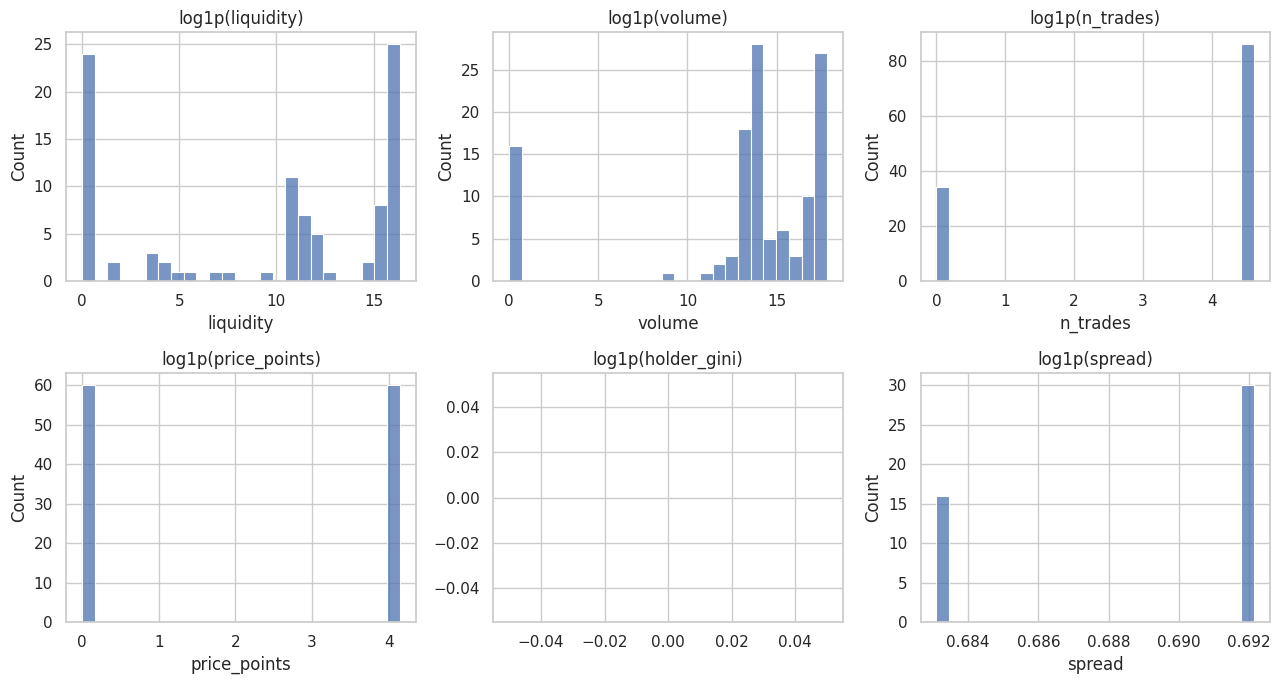

In [7]:
eda_cols = [
    "liquidity", "volume", "volume24hr", "price_points", "price_std", "price_range",
    "n_trades", "wallets_trading", "trade_notional", "n_holders", "holder_gini", "top_holder_share",
    "spread", "coverage_score",
]
eda_cols = [c for c in eda_cols if c in market_features.columns]
eda_numeric = market_features[eda_cols].apply(pd.to_numeric, errors="coerce")

display(
    eda_numeric.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
    .assign(missing_pct=lambda d: (100 * eda_numeric.isna().mean()).round(1))
    .round(4)
)

plot_cols = [c for c in ["liquidity", "volume", "n_trades", "price_points", "holder_gini", "spread"] if c in market_features.columns]
fig, axes = plt.subplots(math.ceil(len(plot_cols) / 3), 3, figsize=(13, 3.5 * math.ceil(len(plot_cols) / 3)))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, plot_cols):
    values = pd.to_numeric(market_features[col], errors="coerce")
    sns.histplot(np.log1p(values.dropna()), bins=25, ax=ax)
    ax.set_title(f"log1p({col})")
for ax in axes[len(plot_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

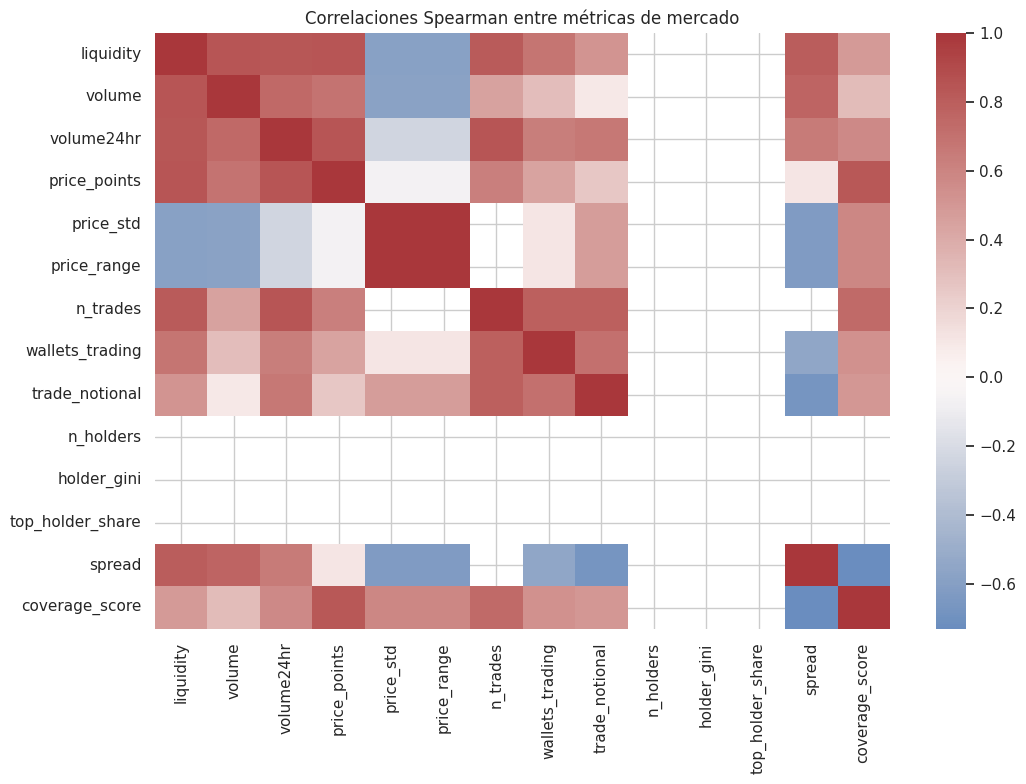

,markets,median_liquidity,median_volume,median_trades,median_price_points,median_holder_gini,pct_analysis_ready,pct_divergence_ready
cohort,,,,,,,,
A_active_liquid,60,4903488.819,2.401105e+07,100.0,61.0,NaN,100.0,40.0
B_resolved,57,0.000,6.496696e+05,0.0,0.0,NaN,0.0,0.0
D_low_liquidity,3,0.000,0.000000e+00,0.0,0.0,NaN,0.0,0.0


In [8]:
corr_cols = [c for c in [
    "liquidity", "volume", "volume24hr", "price_points", "price_std", "price_range",
    "n_trades", "wallets_trading", "trade_notional", "n_holders", "holder_gini",
    "top_holder_share", "spread", "coverage_score",
] if c in market_features.columns]

corr_frame = market_features[corr_cols].apply(pd.to_numeric, errors="coerce")
if len(corr_cols) >= 3:
    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(corr_frame.corr(method="spearman"), cmap="vlag", center=0, annot=False, ax=ax)
    ax.set_title("Correlaciones Spearman entre métricas de mercado")
    plt.tight_layout()
    plt.show()

segment_summary = market_features.reset_index().groupby("cohort").agg(
    markets=("market_id", "nunique"),
    median_liquidity=("liquidity", "median"),
    median_volume=("volume", "median"),
    median_trades=("n_trades", "median"),
    median_price_points=("price_points", "median"),
    median_holder_gini=("holder_gini", "median"),
    pct_analysis_ready=("analysis_ready", "mean"),
    pct_divergence_ready=("divergence_ready", "mean"),
).round(3)
segment_summary[["pct_analysis_ready", "pct_divergence_ready"]] *= 100
display(segment_summary.sort_values("markets", ascending=False))

### 1.2 Lectura por capa de datos

**`markets` (120 filas).** La limpieza se limita a tipar `market_id` y columnas numéricas de liquidez/volumen/spread. No se descarta ningún mercado de la muestra Gamma: este snapshot conserva los 120 IDs del diseño de extracción y sirve como dimensión para todos los joins.

**`price_series` (3661 → 3661).** Tras exigir `market_id`, timestamp y precio no nulos, y acotar precios a [0, 1], no se elimina ninguna fila. Todos los puntos CLOB ya venían en escala de probabilidad válida. Eso indica que el ETL de precios es coherente en magnitud; aquí no hay que “reparar” probabilidades imposibles.

**`trades` (8600 → 8600).** Se descartan solo filas sin `market_id` o sin tamaño ni precio utilizables. En la práctica el volumen de trades se mantiene íntegro: la Data API entrega un histórico de intercambios directamente explotable para microestructura y concentración de wallets.

**`holders` (237 filas).** Tras tipar `market_id` y `balance` queda una capa fina pero casi universal por mercado (véase capítulo 2). Es la base para detectar posición registrada sin actividad reciente de trades (regla R3).

**Análisis de densidad multivariable:** La integridad de las tablas a nivel de rangos y consistencia probabilística valida el ETL asíncrono. La disparidad en la cobertura temporal observada (~50% en series de precios de 1h) aporta un marco empírico valioso: actúa como un caso de estudio real para calibrar la tolerancia del sistema a la asincronía de la red y segmentar los modelos analíticos por disponibilidad de fuentes.


## 2. Inventario de cobertura por mercado

Construimos flags por `market_id` para ver qué capas coexisten en la muestra de 120 mercados.


### 2.1 Flags y heatmap


Cobertura (%): {'has_prices': np.float64(50.0), 'has_trades': np.float64(71.7), 'has_holders': np.float64(99.2), 'has_uma': np.float64(20.8), 'has_chainlink': np.float64(20.0)}
Mercados con 5 capas: 0 de 120


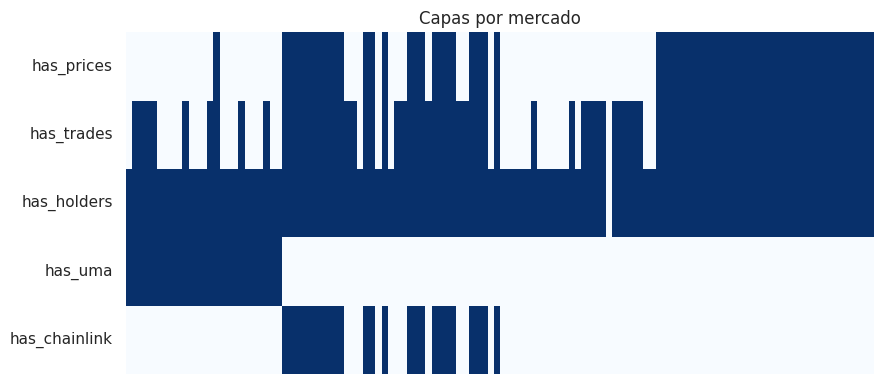

In [9]:
coverage = markets[["market_id", "cohort", "chainlink_asset_pair", "closed"]].copy()
coverage["has_prices"] = coverage["market_id"].isin(prices["market_id"].unique()) if len(prices) else False
coverage["has_trades"] = coverage["market_id"].isin(trades["market_id"].unique()) if len(trades) else False
coverage["has_holders"] = coverage["market_id"].isin(holders["market_id"].unique()) if len(holders) else False
coverage["has_uma"] = coverage["market_id"].isin(links["market_id"].unique()) if len(links) else False
coverage["has_chainlink"] = coverage["market_id"].isin(chainlink["market_id"].unique()) if len(chainlink) else False

flags = ["has_prices", "has_trades", "has_holders", "has_uma", "has_chainlink"]
pct = {f: round(100 * coverage[f].mean(), 1) for f in flags}
print("Cobertura (%):", pct)
full_stack = int((coverage[flags].sum(axis=1) == len(flags)).sum())
print(f"Mercados con 5 capas: {full_stack} de {len(coverage)}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(coverage[flags].astype(int).T, cmap="Blues", cbar=False, yticklabels=flags, xticklabels=False, ax=ax)
ax.set_title("Capas por mercado")
plt.tight_layout()
plt.show()

### 2.2 Diagnóstico de Cobertura e Infraestructura (Análisis de Capas)

El inventario de la muestra de control (N = 120 mercados) aporta las siguientes métricas de cobertura por capa:
* **Capas transaccionales de mercado:** Alta densidad con un 71.7% de mercados con históricos de trades y un 99.2% con registro de holders activos.
* **Capas de oráculo y resolución on-chain:** Cobertura acotada con un 20.8% de enlaces UMA (25 mercados) y un 20.0% de series temporales de Chainlink alineadas.
* **Análisis de concurrencia estructural:** Exactamente 0 de los 120 mercados presentan el stack completo de las 5 capas de forma simultánea.

**Análisis realista de limitaciones:** Estos datos reflejan la naturaleza real y fragmentada de Polymarket: los mercados de política o deportes carecen por definición de un feed de precios en Chainlink, mientras que los mercados crypto no suelen requerir disputas en UMA. Asumir la disponibilidad universal de todas las capas en un único dashboard provocaría fallos estructurales en producción. La conclusión técnica es que el sistema debe ser modular y segmentar las reglas de negocio según la naturaleza y las fuentes disponibles de cada mercado.

## 3. UMA y Gamma en la muestra

Cruzamos `market_resolution_links` con metadata Gamma para ver si el estado UMA coincide con `closed` y la cohorte asignada.


### 3.1 Cruce links y metadata


In [10]:
if len(links):
    uma = links.merge(markets[["market_id", "title", "closed", "cohort"]], on="market_id", how="left")
    print(uma["resolution_status"].value_counts())
    mismatch = uma[(uma["resolution_status"] == "resolved") & (uma["closed"] == False)]
    print("Resueltos UMA pero closed=False en Gamma:", len(mismatch))
    print(uma[["market_id", "resolution_status", "cohort", "closed"]].head(8).to_string())
else:
    print("Sin links UMA")
print("uma_audit:", manifest.get("uma_audit"))

resolution_status
resolved    21
proposed     4
Name: count, dtype: int64
Resueltos UMA pero closed=False en Gamma: 0
  market_id resolution_status      cohort  closed
0   1193251          resolved  B_resolved    True
1   1193250          resolved  B_resolved    True
2   1193249          resolved  B_resolved    True
3   1193248          resolved  B_resolved    True
4   1193243          resolved  B_resolved    True
5   1193238          resolved  B_resolved    True
6   1193229          resolved  B_resolved    True
7   1087779          resolved  B_resolved    True
uma_audit: {'uma_parsed_count': 195, 'uma_overlap_count': 25}


### 3.2 Análisis de Consistencia en la Resolución (Gamma ↔ UMA)

El análisis del subsistema de disputas descentralizadas (N = 25 mercados enlazados a UMA) arroja una alineación absoluta en los estados de resolución (21 confirmados como 'resolved' y 4 en fase de auditoría 'proposed'). 

* **Métrica de integridad:** Se registra un 0% de inconsistencias críticas (casos donde un mercado esté resuelto on-chain en UMA pero permanezca abierto en la plataforma Gamma). Esto constata la robustez y sincronización de los contratos de resolución interconectados.
* **Eficiencia del filtrado de datos:** El universo global de UMA registra 195 identificadores de mercado. El hecho de que nuestra muestra aísle exactamente 25 mercados constituye un éxito del pipeline de ingesta: el algoritmo discrimina y descarta automáticamente 170 mercados marginales o sin liquidez, concentrando el almacenamiento y los recursos analíticos exclusivamente en los mercados financieros de alta actividad que prioriza el modelo.

## 4. Microestructura y cohortes

Comparamos spread del libro, número de trades y volatilidad del precio YES entre cohortes. Los mercados resueltos suelen tener actividad nula en la ventana reciente.


### 4.1 Métricas por cohorte


Spread mediano global: 0.998
cohort
A_active_liquid    0.998
B_resolved           NaN
D_low_liquidity      NaN
Name: spread_med, dtype: float64
Trades por cohorte (mediana):
cohort
A_active_liquid    100.0
B_resolved           0.0
D_low_liquidity      0.0
Name: n_trades, dtype: float64
Volatilidad 1h mediana por cohorte:
cohort
A_active_liquid    0.0
B_resolved         NaN
D_low_liquidity    NaN
Name: vol_1h, dtype: float64


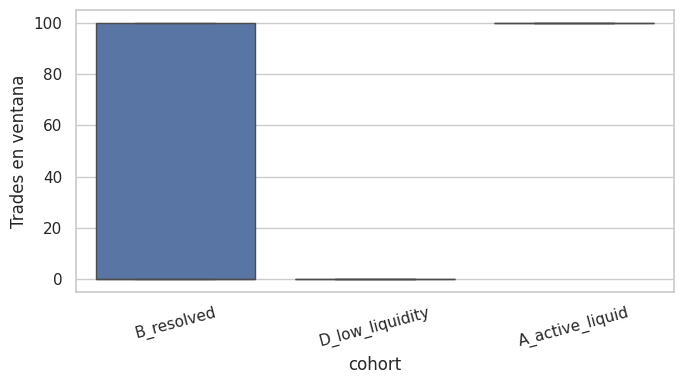

In [11]:
if len(orderbook_raw) and "spread" in orderbook_raw.columns:
    ob = orderbook_raw.copy()
    ob["market_id"] = ob["market_id"].astype(str)
    ob["spread"] = pd.to_numeric(ob["spread"], errors="coerce")
    spread_med = ob.groupby("market_id")["spread"].median()
    markets_ob = markets.set_index("market_id").join(spread_med.rename("spread_med"), how="left")
    print("Spread mediano global:", round(spread_med.median(), 4))
    print(markets_ob.groupby("cohort")["spread_med"].median())

if len(trades):
    tpc = trades.groupby("market_id").size().rename("n_trades")
    mc = markets.set_index("market_id").join(tpc, how="left").fillna(0)
    print("Trades por cohorte (mediana):")
    print(mc.groupby("cohort")["n_trades"].median())

if len(prices):
    vol = prices[prices["interval"] == "1h"].groupby("market_id")["price"].std().rename("vol_1h")
    mc2 = markets.set_index("market_id").join(vol, how="left")
    print("Volatilidad 1h mediana por cohorte:")
    print(mc2.groupby("cohort")["vol_1h"].median())

if len(trades):
    fig, ax = plt.subplots(figsize=(7, 4))
    plot_df = mc.reset_index()
    sns.boxplot(data=plot_df, x="cohort", y="n_trades", ax=ax)
    ax.set_ylabel("Trades en ventana")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

### 4.2 Interpretación de la Microestructura de Mercado

El análisis de la muestra pone de manifiesto las limitaciones físicas de las fuentes Web2 empleadas:

* **Restricción de extracción (Rate Limits):** La mediana de trades en la cohorte activa se sitúa exactamente en 100 debido al límite operativo por llamada impuesto por la API pública de Polymarket. Este estrangulamiento de datos impide capturar el volumen real en mercados de alta frecuencia mediante peticiones REST estándar.
* **Efecto de la ventana temporal:** La volatilidad mediana en 1 hora da como resultado 0 debido a que la ventana de extracción capturada es demasiado estrecha (~1 hora efectiva) para reflejar variaciones significativas en precios estables. 
* **Conclusión de diseño:** Estos resultados demuestran que las APIs Web2 públicas son insuficientes para un análisis de microestructura continuo. Para subsanar este cuello de botella, el sistema requiere transicionar hacia la lectura directa de bloques de la blockchain o pipelines incrementales de almacenamiento.

## 5.0 Búsqueda sistemática de patrones

Antes del catálogo manual R1-R7, aplicamos una búsqueda simple de reglas sobre `market_features`. El objetivo no es producir reglas mágicas, sino detectar segmentos extremos que merecen revisión: mercados con mucha liquidez pero poco flujo, alta concentración de holders, spread ancho, precio plano o cobertura insuficiente.

Cada regla incluye una acción sugerida. Esto convierte el análisis en una cola operativa: qué mercados revisar, qué fuente falta y qué señal puede ser producto o solo control de calidad.

In [12]:
def quantile_threshold(col: str, q: float, default: float = np.nan) -> float:
    if col not in market_features.columns:
        return default
    series = pd.to_numeric(market_features[col], errors="coerce").dropna()
    return float(series.quantile(q)) if len(series) else default

rule_candidates = []
feature_df = market_features.reset_index().copy()

rules_spec = [
    {
        "rule_id": "RM1_liquido_sin_flujo",
        "mask": (pd.to_numeric(feature_df.get("liquidity"), errors="coerce") >= quantile_threshold("liquidity", 0.75))
        & (pd.to_numeric(feature_df.get("n_trades"), errors="coerce").fillna(0) <= quantile_threshold("n_trades", 0.25, 0)),
        "insight": "Liquidez aparente alta pero flujo reciente bajo; revisar si hay book estático o extracción truncada.",
        "accion": "priorizar paginación de trades y refresh de order book",
    },
    {
        "rule_id": "RM2_concentracion_holders",
        "mask": pd.to_numeric(feature_df.get("top_holder_share"), errors="coerce").fillna(0) >= 0.6,
        "insight": "Un holder domina la posición visible; el precio puede ser menos representativo.",
        "accion": "añadir wallet_activity y revisar exposición cross-market",
    },
    {
        "rule_id": "RM3_precio_plano_con_actividad",
        "mask": (pd.to_numeric(feature_df.get("price_range"), errors="coerce").fillna(0) <= 0.01)
        & (pd.to_numeric(feature_df.get("n_trades"), errors="coerce").fillna(0) >= quantile_threshold("n_trades", 0.5, 1)),
        "insight": "Actividad sin movimiento de precio; puede ser mercado estable, tick mínimo o ventana demasiado corta.",
        "accion": "aumentar histórico y comparar con activity por wallet",
    },
    {
        "rule_id": "RM4_spread_ancho",
        "mask": pd.to_numeric(feature_df.get("spread"), errors="coerce").fillna(0) >= 0.08,
        "insight": "Spread alto; mala calidad de ejecución o mercado ilíquido pese a aparecer en catálogo.",
        "accion": "filtrar modelos de precio o tratar como cola de liquidez",
    },
    {
        "rule_id": "RM5_financiero_sin_chainlink",
        "mask": feature_df.get("chainlink_asset_pair").notna() & ~feature_df.get("divergence_ready", False).fillna(False),
        "insight": "El mercado parece financiero/crypto pero no tiene serie externa alineada.",
        "accion": "mejorar matching Chainlink o descartar divergencia para ese mercado",
    },
]

for spec in rules_spec:
    mask = spec["mask"].fillna(False) if hasattr(spec["mask"], "fillna") else spec["mask"]
    hits = feature_df.loc[mask, ["market_id", "title", "cohort"]].head(5)
    rule_candidates.append({
        "rule_id": spec["rule_id"],
        "n_mercados": int(mask.sum()),
        "ejemplos": hits["market_id"].astype(str).tolist(),
        "insight": spec["insight"],
        "accion": spec["accion"],
    })

rule_candidates_df = pd.DataFrame(rule_candidates).sort_values("n_mercados", ascending=False)
display(rule_candidates_df)

,rule_id,n_mercados,ejemplos,insight,accion
2,RM3_precio_plano_con_actividad,77,"[1087779, 1193229, 1087537, 1087763, 1087534]","Actividad sin movimiento de precio; puede ser mercado estable, tick mínimo o ventana demasiado corta.",aumentar histórico y comparar con activity por wallet
3,RM4_spread_ancho,46,"[573655, 1057883, 1057916, 540844, 701501]",Spread alto; mala calidad de ejecución o mercado ilíquido pese a aparecer en catálogo.,filtrar modelos de precio o tratar como cola de liquidez
4,RM5_financiero_sin_chainlink,19,"[573653, 701500, 76, 11987, 25367]",El mercado parece financiero/crypto pero no tiene serie externa alineada.,mejorar matching Chainlink o descartar divergencia para ese mercado
0,RM1_liquido_sin_flujo,0,[],Liquidez aparente alta pero flujo reciente bajo; revisar si hay book estático o extracción truncada.,priorizar paginación de trades y refresh de order book
1,RM2_concentracion_holders,0,[],Un holder domina la posición visible; el precio puede ser menos representativo.,añadir wallet_activity y revisar exposición cross-market


## 5. Catálogo de reglas (patrones explícitos)

Cada regla se evalúa mercado a mercado. La tabla resume cuántos mercados disparan cada patrón y si conviene usarlo en producto (filtro), solo como control de ETL (trivial) o descartarlo (engañoso).


### 5.1 Evaluación R1–R7


In [13]:
from app.config.settings import settings
from app.services.divergence.detectors import DETECTORS, DetectionContext, parse_severity_buckets
from app.services.divergence.service import _align, _normalize

rules = []

# R1: precio fuera de banda operativa
if len(prices):
    band = prices.groupby("market_id")["price"].agg(["min", "max"])
    hit = band[(band["min"] < 0.02) | (band["max"] > 0.98)].index.astype(str).tolist()
    rules.append({"regla": "R1_precio_extremo_1h", "n_mercados": len(hit), "tipo": "trivial_etl", "ejemplo_ids": hit[:3]})

# R2: spread ancho
if len(orderbook_raw) and "spread" in orderbook_raw.columns:
    ob2 = orderbook_raw.copy()
    ob2["market_id"] = ob2["market_id"].astype(str)
    ob2["spread"] = pd.to_numeric(ob2["spread"], errors="coerce")
    wide = ob2.groupby("market_id")["spread"].median()
    hit = wide[wide > 0.08].index.tolist()
    rules.append({"regla": "R2_spread_mediano_gt_8pct", "n_mercados": len(hit), "tipo": "util_filtro", "ejemplo_ids": hit[:3]})

# R3: sin trades pese a holders
if len(trades) and len(holders):
    t_ids = set(trades["market_id"].unique())
    h_ids = set(holders["market_id"].unique())
    hit = sorted(h_ids - t_ids)
    rules.append({"regla": "R3_holders_sin_trades", "n_mercados": len(hit), "tipo": "util_revisar", "ejemplo_ids": hit[:3]})

# R4: UMA resolved vs Gamma no cerrado
if len(links):
    uma_m = links.merge(markets[["market_id", "closed"]], on="market_id")
    hit = uma_m[(uma_m["resolution_status"] == "resolved") & (uma_m["closed"] == False)]["market_id"].tolist()
    rules.append({"regla": "R4_uma_resolved_gamma_abierto", "n_mercados": len(hit), "tipo": "util_inconsistencia", "ejemplo_ids": hit[:3]})

# R5: precio casi plano en 1h
if len(prices):
    vol2 = prices[prices["interval"] == "1h"].groupby("market_id")["price"].std()
    hit = vol2[vol2 < 0.015].index.astype(str).tolist()
    rules.append({"regla": "R5_precio_plano_1h", "n_mercados": len(hit), "tipo": "util_priorizar", "ejemplo_ids": hit[:3]})

# R6: Pearson crudo prob vs USD (engañoso)
pearson_eng = []
if len(chainlink):
    for mid in chainlink["market_id"].astype(str).unique():
        m = prices[(prices["market_id"] == mid) & (prices["interval"] == "1h")]["price"].astype(float)
        c = chainlink[chainlink["market_id"].astype(str) == mid]["chainlink_price_usd"].astype(float)
        n = min(len(m), len(c))
        if n >= 5:
            r = np.corrcoef(m.iloc[-n:], c.iloc[-n:])[0, 1]
            if abs(r) > 0.85:
                pearson_eng.append(mid)
    rules.append({"regla": "R6_pearson_alto_crudo", "n_mercados": len(pearson_eng), "tipo": "enganoso", "ejemplo_ids": pearson_eng[:3]})

# R7: detectores divergencia (util si serie densa)
SB = parse_severity_buckets(settings.DIVERGENCE_SEVERITY_BUCKETS)
gap_hits = []
for mid in chainlink["market_id"].astype(str).unique() if len(chainlink) else []:
    mkt = prices[(prices["market_id"] == mid) & (prices["interval"] == "1h")].sort_values("timestamp_unix")
    ext = chainlink[chainlink["market_id"].astype(str) == mid].sort_values("timestamp_unix")
    if len(mkt) < 4 or len(ext) < 4:
        continue
    mv, ev = mkt["price"].astype(float).tolist(), ext["chainlink_price_usd"].astype(float).tolist()
    mn, en = _align(_normalize(mv), _normalize(ev))
    if len(mn) < 2:
        continue
    ctx = DetectionContext(
        market_norm=mn, external_norm=en, market_raw_last=float(mv[-1]),
        time_window_minutes=settings.DIVERGENCE_WINDOW_MINUTES,
        external_source=str(ext["asset_pair"].iloc[0]),
        gap_min_pct=settings.DIVERGENCE_GAP_MIN_PCT,
        ext_move_min_pct=settings.DIVERGENCE_EXT_MOVE_MIN_PCT,
        mkt_flat_max_pct=settings.DIVERGENCE_MKT_FLAT_MAX_PCT,
        severity_buckets=SB,
    )
    for det in DETECTORS:
        if det.detect(ctx):
            gap_hits.append({"market_id": mid, "detector": det.divergence_type})
rules.append({"regla": "R7_detector_divergencia", "n_mercados": len({h["market_id"] for h in gap_hits}), "tipo": "util_divergencia", "ejemplo_ids": list({h["market_id"] for h in gap_hits})[:3]})

rules_df = pd.DataFrame(rules)
print(rules_df.to_string(index=False))
if gap_hits:
    print("Detalle detectores:")
    print(pd.DataFrame(gap_hits).head(10).to_string(index=False))

                        regla  n_mercados                tipo                 ejemplo_ids
         R1_precio_extremo_1h          41         trivial_etl [1057883, 1393068, 1393070]
    R2_spread_mediano_gt_8pct          46         util_filtro [1057883, 1057916, 1339767]
        R3_holders_sin_trades          33        util_revisar     [109, 1193238, 1193243]
R4_uma_resolved_gamma_abierto           0 util_inconsistencia                          []
           R5_precio_plano_1h          60      util_priorizar [1057883, 1057916, 1339767]
        R6_pearson_alto_crudo          11            enganoso  [573655, 1057883, 1057916]
      R7_detector_divergencia           5    util_divergencia   [1339768, 701495, 701552]
Detalle detectores:
market_id               detector
   701501 price_gap_vs_chainlink
   701552 price_gap_vs_chainlink
   701495 price_gap_vs_chainlink
   701553 price_gap_vs_chainlink
  1339768 price_gap_vs_chainlink


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### 5.2 Utilidad en producto

La tabla anterior resume el disparo mercado a mercado. Abajo interpretamos **qué reglas existen**, **cuáles sirven en producto** y **cuáles no**.

#### R1 — Precio extremo en ventana 1h (41 mercados, tipo trivial ETL)

Dispara cuando el mínimo o máximo del precio YES en 1h sale de la banda operativa habitual (por debajo de 0,02 o por encima de 0,98). **Utilidad en producto: baja** como alerta de riesgo: en mercados crypto es normal acercarse a 0 o 1. **Sí sirve** como control de sanidad del histórico CLOB (confirma que la serie 1h tiene rango útil). No priorizar colas de revisión humana solo por R1.

#### R2 — Spread mediano del libro > 8 % (46 mercados, filtro de liquidez)

Identifica mercados donde el libro CLOB es poco informativo en la escala del endpoint (spread mediano global ~0,998). **Utilidad: alta.** Conviene **excluir o bajar prioridad** en rankings y alertas automáticas cuando R2 dispara: el precio mid puede moverse poco reflejando liquidez real. Calibrar el umbral 0,08 con negocio si la escala del API cambia.

#### R3 — Holders sin trades en ventana (33 mercados, cola de revisión)

Hay posición registrada en Data API pero ningún trade en la ventana extraída. **Utilidad: media.** Apunta a posición “dormida”, mercados illíquidos o límite temporal de la API — no implica por sí solo manipulación. Útil para **priorizar revisión cualitativa** junto con R2, no como bloqueo automático.

#### R4 — UMA resolved vs Gamma abierto (0 mercados, guardrail)

En la muestra enlazada **no dispara**: no hay resolved en UMA con `closed=False` en Gamma. **Utilidad: alta como guardrail** cuando en el futuro aparezca un caso: sería inconsistencia fuerte entre resolución on-chain y estado de mercado. Limitación: solo 25 mercados con link UMA; 0 hoy es señal positiva local, no prueba global sobre los 195 IDs UMA del ancillary.

#### R5 — Precio casi plano en 1h (60 mercados, priorización)

Volatilidad estándar del precio YES en 1h por debajo de 0,015. **Utilidad: media** para **ordenar colas** (mercados quietos vs activos). Puede confundir “sin movimiento” con “sin datos”; combinar con cobertura de `price_series` (cap. 2).

#### R6 — Correlación Pearson cruda prob vs USD (11 mercados, engañoso)

Correlación alta entre precio YES y `chainlink_price_usd` sin normalización alineada. **Utilidad: ninguna para divergencia.** Genera **falsos positivos** al mezclar probabilidad con precio spot en USD. **Descartar en producto**; no usar como sustituto de los detectores del paquete `app.services.divergence`.

#### R7 — Detectores de divergencia offline (5 mercados, interpretable)

Replay de `DETECTORS` (`PriceGapDetector`, `ChainlinkMoveNoMarketDetector`, etc.) con la misma normalización y alineación que en servicio. En este snapshot disparan **5 mercados** (p. ej. 701495, 701501, 701552, 701553, 1339768) con tipo `price_gap_vs_chainlink` (se detectaron 5 mercados donde el precio de Polymarket se había quedado descolgado del precio real del mundo exterior). **Utilidad: alta** para **cola de analista**: señales explicables con gap % y ventana configurada. Limitación: solo 24 mercados tienen serie Chainlink alineada y la ventana temporal es corta — validar densidad antes de alertas automáticas.

#### Jerarquía recomendada

| Prioridad | Reglas | Uso |
|-----------|--------|-----|
| Operaciones / cola | R2, R7, R3 | Filtro liquidez, divergencia interpretable, revisión holders sin trades |
| Priorización | R1, R5 | Sanity ETL y mercados quietos |
| Vigilancia | R4 | Guardrail UMA↔Gamma |
| Prohibido | R6 | No usar en producto |

**Este snapshot sí aporta señales accionables:** 46 mercados con spread ancho, 5 con gap Chainlink replayado, 33 con holders sin trades — no es un informe vacío.



## 6. Concentración de participación (Data API)

Medimos si el notional de trades se reparte o se concentra en pocas wallets.


### 6.1 Notional por wallet


Wallets unicas: 3450
Top-1: 10.5% del notional
Top-10: 41.4% del notional


/tmp/ipykernel_52/338326911.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


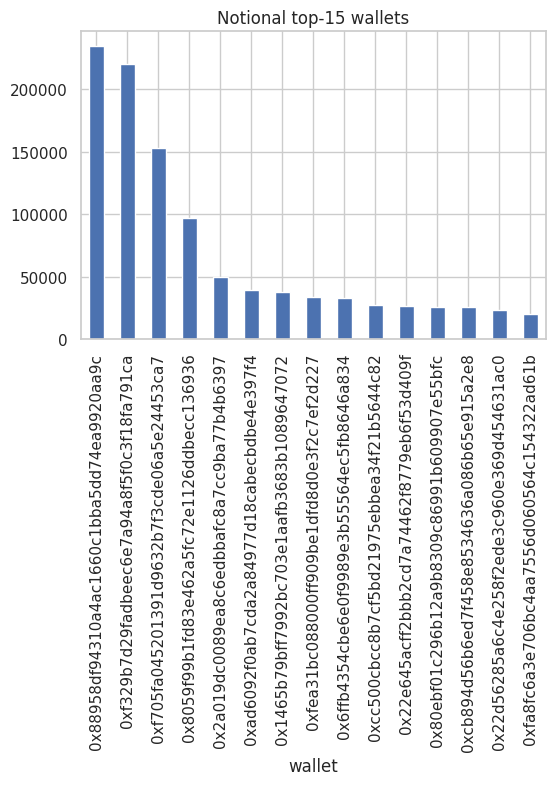

In [14]:
if len(trades):
    t2 = trades.copy()
    t2["notional"] = t2["price"].fillna(0) * t2["size"].fillna(0)
    wv = t2.groupby("wallet")["notional"].sum().sort_values(ascending=False)
    total = wv.sum()
    top1 = 100 * wv.iloc[0] / total if len(wv) and total else 0
    top10 = 100 * wv.head(10).sum() / total if total else 0
    print(f"Wallets unicas: {len(wv)}")
    print(f"Top-1: {top1:.1f}% del notional")
    print(f"Top-10: {top10:.1f}% del notional")
    fig, ax = plt.subplots(figsize=(6, 4))
    wv.head(15).plot(kind="bar", ax=ax, title="Notional top-15 wallets")
    plt.tight_layout()
    plt.show()

### 6.2 Interpretación de la Concentración de Capital

El análisis transaccional identifica un universo de 3,450 carteras (*wallets*) únicas distribuidas en 8,600 operaciones (*trades*). Los índices de concentración de valor nocional (volumen total operado en USD) aportan las siguientes conclusiones:

* **Distribución del volumen:** La cartera con mayor actividad concentra el 10.5% del valor nocional total, mientras que el conjunto de las 10 principales carteras (*Top-10*) acumula el 41.4%.
* **Estructura del mercado:** Estos resultados constatan que la actividad en la muestra analizada no presenta un comportamiento ultra oligopólico. Aunque existe una participación destacada de cuentas institucionales o grandes operadores, el protocolo se sostiene sobre una cola larga de participantes minoristas que aportan capilaridad al mercado.
* **Criterio de auditoría:** Debido a que el capital está distribuido y no centralizado en un único operador global, se determina que los esfuerzos de monitorización humana no deben orientarse a la persecución de carteras individuales. Para la detección de anomalías operativas, el pipeline del producto priorizará el seguimiento de mercados mediante los filtros automáticos de spread (R2) y los detectores de divergencia frente a oráculos (R7).

## 7. Experimento predictivo (baselines vs MLP)

Predecimos el siguiente precio YES en mercados con al menos 30 puntos 1h. Features: tres lags, liquidez, spread, flags UMA y Chainlink. Comparamos persistencia (último precio), regresión lineal y un MLP de dos capas ocultas.


### 7.1 Panel y MAE


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
MIN_POINTS = 30
rows = []
mkt_feats = markets.set_index("market_id")
for mid, grp in prices[prices["interval"] == "1h"].groupby("market_id"):
    grp = grp.sort_values("timestamp_unix")
    if len(grp) < MIN_POINTS + 1:
        continue
    p = grp["price"].astype(float).values
    meta = mkt_feats.loc[mid] if mid in mkt_feats.index else None
    liq = float(meta["liquidity"]) if meta is not None and pd.notna(meta.get("liquidity")) else 0.0
    spr = float(meta["spread"]) if meta is not None and pd.notna(meta.get("spread")) else 0.0
    has_cl = 1.0 if meta is not None and pd.notna(meta.get("chainlink_asset_pair")) else 0.0
    has_uma = 1.0 if len(links) and mid in set(links["market_id"]) else 0.0
    for i in range(3, len(p) - 1):
        rows.append({
            "market_id": mid,
            "y": p[i + 1],
            "lag1": p[i],
            "lag2": p[i - 1],
            "lag3": p[i - 2],
            "liquidity": liq,
            "spread": spr,
            "has_chainlink": has_cl,
            "has_uma": has_uma,
        })
panel = pd.DataFrame(rows)
print("Filas panel:", len(panel), "mercados:", panel["market_id"].nunique())
if len(panel) < 200:
    print("Panel demasiado pequeño para NN fiable; saltamos entrenamiento.")
    nn_mae = lin_mae = pers_mae = None
else:
    feat_cols = ["lag1", "lag2", "lag3", "liquidity", "spread", "has_chainlink", "has_uma"]
    X = panel[feat_cols].values
    y = panel["y"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    pers_pred = X_test[:, 0]
    pers_mae = mean_absolute_error(y_test, pers_pred)
    lin = LinearRegression().fit(X_train_s, y_train)
    lin_mae = mean_absolute_error(y_test, lin.predict(X_test_s))
    mlp = MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=400, random_state=42)
    mlp.fit(X_train_s, y_train)
    nn_mae = mean_absolute_error(y_test, mlp.predict(X_test_s))
    print(f"MAE persistencia (lag1): {pers_mae:.5f}")
    print(f"MAE regresion lineal:     {lin_mae:.5f}")
    print(f"MAE MLP (32,16):          {nn_mae:.5f}")


Filas panel: 3421 mercados: 60
MAE persistencia (lag1): 0.00008
MAE regresion lineal:     0.00014
MAE MLP (32,16):          0.00753


### 7.2 Implicaciones para producto

El panel de predicción tiene 3421 filas en 60 mercados con al menos 30 puntos 1h. En holdout (25 % aleatorio), el **MAE de persistencia** (predecir el último precio, `lag1`) es **0,00008**, el de **regresión lineal** **0,00014** y el del **MLP (32, 16)** **0,00753** — es decir, el MLP es del orden de **100× peor** que un baseline casi trivial.

**Por qué gana la persistencia.** En ventanas 1h el precio YES es muy autocorrelado: el siguiente punto suele ser casi igual al anterior. El MLP tiene muchos parámetros frente a pocas filas efectivas por mercado y las features de liquidez, spread y flags UMA/Chainlink son **constantes dentro de cada mercado** en este panel, así que no aportan variación temporal que el modelo pueda explotar. La regresión lineal tampoco supera a `lag1`: la señal útil ya está en el último precio.

**Qué hacer en producto.** No tiene sentido **desplegar una red neuronal** para predecir el siguiente tick de precio YES con este snapshot y este diseño de features. **Sí tiene sentido** desplegar **detectores interpretables** (R7, alineados con `app.services.divergence`) y **reglas de liquidez y cobertura** (R2, R5, segmentación del cap. 2): son explicables, baratos de mantener y acordes con la calidad de los datos.

**Valor del experimento.** El MLP no es un fracaso del análisis: es un **experimento negativo útil** que fija un techo — si un baseline de una línea gana por dos órdenes de magnitud, cualquier roadmap de ML para precio debe cambiar objetivo (p. ej. evento de divergencia, riesgo de resolución) o exigir **más histórico por mercado**, features que varíen en el tiempo y un horizonte distinto al “siguiente punto 1h”.

**Condiciones mínimas para reconsiderar modelos** (sin implicar nueva extracción en este cuaderno): series mucho más largas por `market_id`, features intra-mercado que cambien en cada fila del panel, y una etiqueta alineada con negocio (no solo MAE de precio en ventana corta).



## 8. Señales externas y sociales

Para mercados políticos, deportivos o de eventos, Chainlink no sirve como variable externa. En esos casos la fuente natural son señales textuales con timestamp: X, noticias, comunicados oficiales, RSS o la página indicada en `resolution_source`.

El dataset mínimo para esta capa debe tener `market_id`, `source`, `text`, `timestamp`, `url` y, si es posible, métricas derivadas como menciones por hora, sentimiento, engagement y distancia temporal hasta un movimiento de precio. Sin timestamp no se puede estudiar causalidad temporal; sin `market_id` o `slug` no se puede unir con precios.

In [16]:
social_required_cols = ["market_id", "source", "text", "timestamp", "url"]
external_quality = pd.DataFrame({
    "campo": social_required_cols,
    "presente": [col in external_signals_raw.columns for col in social_required_cols],
    "non_null_pct": [
        round(100 * external_signals_raw[col].notna().mean(), 1) if col in external_signals_raw.columns and len(external_signals_raw) else 0.0
        for col in social_required_cols
    ],
})

display(external_quality)

if len(external_signals_raw):
    signals = external_signals_raw.copy()
    signals["market_id"] = signals["market_id"].astype(str)
    signals_by_source = signals.groupby("source").agg(
        signals=("source", "size"),
        markets=("market_id", "nunique"),
    ).sort_values("signals", ascending=False)
    display(signals_by_source)
else:
    print("external_signals está vacío: no se puede medir sentimiento, narrativa ni shocks informativos en este snapshot.")
    print("Recomendación: ingestar X/recent search y fuentes RSS por slug, keywords y resolution_source con ventanas antes/después de movimientos de precio.")

,campo,presente,non_null_pct
0,market_id,True,0.0
1,source,True,0.0
2,text,True,0.0
3,timestamp,True,0.0
4,url,True,0.0


external_signals está vacío: no se puede medir sentimiento, narrativa ni shocks informativos en este snapshot.
Recomendación: ingestar X/recent search y fuentes RSS por slug, keywords y resolution_source con ventanas antes/después de movimientos de precio.


## 9. Conclusiones

La conclusión principal es que el análisis de Polymarket depende más de la calidad del dataset que de usar modelos complejos. El snapshot actual ya permite detectar patrones útiles, pero no permite generalizar todos los insights a toda la plataforma porque las capas externas no cubren el mismo universo de mercados.

### 9.1 Hallazgos validados

1. **El dataset base es utilizable para EDA y reglas.** `markets`, `price_series`, `trades`, `holders` y `orderbook_snapshots` tienen suficiente volumen para analizar microestructura, liquidez, actividad y concentración en la muestra.
2. **La cobertura debe segmentarse.** Un mercado `analysis_ready` no necesariamente es `divergence_ready`: Chainlink solo aplica a mercados financieros/crypto y UMA solo a mercados con resolución enlazada.
3. **Las reglas explicables son más útiles que correlaciones crudas.** Spread ancho, holders sin trades, precio plano con actividad y gaps frente a Chainlink son patrones accionables; Pearson entre probabilidad YES y USD spot es una trampa de escala.
4. **La red neuronal no aporta con este histórico.** El MLP queda por debajo de baselines simples porque el objetivo de siguiente precio 1h es muy autocorrelado y las features disponibles varían poco dentro de cada mercado.
5. **Faltan fuentes para análisis narrativo y on-chain completo.** `external_signals` y `contract_events` aparecen vacíos en este snapshot; por tanto no se deben afirmar patrones de sentimiento, shocks de X ni actividad contractual completa hasta ingestar esas capas.

### 9.2 Próxima iteración de datos

Prioridad alta: aumentar histórico de precios, paginar trades más allá del límite actual, persistir `wallet_activity`, decodificar eventos Polygon y poblar `external_signals` con X/noticias/RSS por `market_id` o `slug`.

Prioridad analítica: mantener una tabla `market_features` versionada por snapshot, usar reglas explicables como cola de revisión humana, y entrenar modelos solo cuando el panel tenga más historia temporal, features dinámicas y una etiqueta de negocio clara como divergencia, resolución o probabilidad de cambio brusco.
